# **Computational Drug Discovery [Part 2] Exploratory Data Analysis**

In this Jupyter notebook, we will be building a real-life **data science project** that we can include in our **data science project**. Particularly, we will be building a machine learning model using the ChEMBL bioactivity data.

In **Part 2**, we will be performing Descriptor Calculation and Exploratory Data Analysis.

---

## **Install conda and rdkit**

## **Load bioactivity data**

In [1]:
import conda as cd

In [2]:
import pandas as pd

In [3]:
import sys
import pandas as pd
import scipy
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [4]:
import scipy
import csv

In [5]:
csv.file=pd.read_csv(r"C:\Users\86159\Desktop\Final_curated_bioactivity_data.csv")
csv.file

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value
0,CHEMBL382272,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,inactive,3070.0
1,CHEMBL382272,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,active,1600.0
2,CHEMBL383597,CCCCCCCCCCCCCC(=O)N[C@@H](COP(=O)(O)OCCNC(=O)C...,active,900.0
3,CHEMBL372577,CCCCCCCCCCCCCC(=O)N[C@@H](COP(=O)(O)OCCNC(=O)C...,active,950.0
4,CHEMBL380585,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)NC...,inactive,5200.0
5,CHEMBL190383,CCCCCCCCCCCCCC(=O)O[C@H](COCC[C@@H](CCCCCCC)OC...,active,1250.0
6,CHEMBL200206,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,active,2150.0
7,CHEMBL200140,CCCCCCCCCCCCCC(=O)N[C@@H](COCC[C@@H](CCCCCCC)O...,inactive,22000.0
8,CHEMBL200667,CCCCCCCCCCCCCC(=O)N[C@@H](COCC[C@H](CCCCCCC)OC...,inactive,6900.0
9,CHEMBL200398,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@H](CCCCCCC)OC(...,inactive,6460.0


## **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10 

### **Import libraries**

In [6]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### **Calculate descriptors**

In [7]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem) 
        moldata.append(mol)
       
    baseData= np.arange(1,1)
    i=0  
    for mol in moldata:        
       
        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)
           
        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])   
    
        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1      
    
    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]   
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)
    
    return descriptors

In [8]:
csv.file_lipinski = lipinski(csv.file.canonical_smiles)

### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [9]:
csv.file_lipinski
df1=csv.file_lipinski
df1

,MW,LogP,NumHDonors,NumHAcceptors
0,955.265,11.6711,5.0,10.0
1,955.265,11.6711,5.0,10.0
2,968.264,10.7707,6.0,10.0
3,969.248,11.1977,5.0,11.0
4,954.281,11.2441,6.0,9.0
5,956.249,12.0981,4.0,11.0
6,911.256,12.3604,4.0,9.0
7,955.265,11.6711,5.0,10.0
8,955.265,11.6711,5.0,10.0
9,955.265,11.6711,5.0,10.0


In [10]:
df=csv.file
df

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value
0,CHEMBL382272,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,inactive,3070.0
1,CHEMBL382272,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,active,1600.0
2,CHEMBL383597,CCCCCCCCCCCCCC(=O)N[C@@H](COP(=O)(O)OCCNC(=O)C...,active,900.0
3,CHEMBL372577,CCCCCCCCCCCCCC(=O)N[C@@H](COP(=O)(O)OCCNC(=O)C...,active,950.0
4,CHEMBL380585,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)NC...,inactive,5200.0
5,CHEMBL190383,CCCCCCCCCCCCCC(=O)O[C@H](COCC[C@@H](CCCCCCC)OC...,active,1250.0
6,CHEMBL200206,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,active,2150.0
7,CHEMBL200140,CCCCCCCCCCCCCC(=O)N[C@@H](COCC[C@@H](CCCCCCC)O...,inactive,22000.0
8,CHEMBL200667,CCCCCCCCCCCCCC(=O)N[C@@H](COCC[C@H](CCCCCCC)OC...,inactive,6900.0
9,CHEMBL200398,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@H](CCCCCCC)OC(...,inactive,6460.0


Now, let's combine the 2 DataFrame

In [11]:
df_combined = pd.concat([df,df1], axis=1)
df_combined

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL382272,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,inactive,3070.0,955.265,11.6711,5.0,10.0
1,CHEMBL382272,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,active,1600.0,955.265,11.6711,5.0,10.0
2,CHEMBL383597,CCCCCCCCCCCCCC(=O)N[C@@H](COP(=O)(O)OCCNC(=O)C...,active,900.0,968.264,10.7707,6.0,10.0
3,CHEMBL372577,CCCCCCCCCCCCCC(=O)N[C@@H](COP(=O)(O)OCCNC(=O)C...,active,950.0,969.248,11.1977,5.0,11.0
4,CHEMBL380585,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)NC...,inactive,5200.0,954.281,11.2441,6.0,9.0
5,CHEMBL190383,CCCCCCCCCCCCCC(=O)O[C@H](COCC[C@@H](CCCCCCC)OC...,active,1250.0,956.249,12.0981,4.0,11.0
6,CHEMBL200206,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,active,2150.0,911.256,12.3604,4.0,9.0
7,CHEMBL200140,CCCCCCCCCCCCCC(=O)N[C@@H](COCC[C@@H](CCCCCCC)O...,inactive,22000.0,955.265,11.6711,5.0,10.0
8,CHEMBL200667,CCCCCCCCCCCCCC(=O)N[C@@H](COCC[C@H](CCCCCCC)OC...,inactive,6900.0,955.265,11.6711,5.0,10.0
9,CHEMBL200398,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@H](CCCCCCC)OC(...,inactive,6460.0,955.265,11.6711,5.0,10.0


### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [12]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis=1)
        
    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

In [13]:
df_combined.standard_value.describe()

count       31.000000
mean      4004.977419
std       4233.665841
min         48.000000
25%       1075.000000
50%       3373.000000
75%       5100.000000
max      22000.000000
Name: standard_value, dtype: float64

In [14]:
-np.log10( (10**-9)* 100000000 )

1.0

In [15]:
-np.log10( (10**-9)* 10000000000 )

-1.0

In [16]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)
        
    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [17]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL382272,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,inactive,955.265,11.6711,5.0,10.0,3070.0
1,CHEMBL382272,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,active,955.265,11.6711,5.0,10.0,1600.0
2,CHEMBL383597,CCCCCCCCCCCCCC(=O)N[C@@H](COP(=O)(O)OCCNC(=O)C...,active,968.264,10.7707,6.0,10.0,900.0
3,CHEMBL372577,CCCCCCCCCCCCCC(=O)N[C@@H](COP(=O)(O)OCCNC(=O)C...,active,969.248,11.1977,5.0,11.0,950.0
4,CHEMBL380585,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)NC...,inactive,954.281,11.2441,6.0,9.0,5200.0
5,CHEMBL190383,CCCCCCCCCCCCCC(=O)O[C@H](COCC[C@@H](CCCCCCC)OC...,active,956.249,12.0981,4.0,11.0,1250.0
6,CHEMBL200206,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,active,911.256,12.3604,4.0,9.0,2150.0
7,CHEMBL200140,CCCCCCCCCCCCCC(=O)N[C@@H](COCC[C@@H](CCCCCCC)O...,inactive,955.265,11.6711,5.0,10.0,22000.0
8,CHEMBL200667,CCCCCCCCCCCCCC(=O)N[C@@H](COCC[C@H](CCCCCCC)OC...,inactive,955.265,11.6711,5.0,10.0,6900.0
9,CHEMBL200398,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@H](CCCCCCC)OC(...,inactive,955.265,11.6711,5.0,10.0,6460.0


In [18]:
df_norm.standard_value_norm.describe()

count       31.000000
mean      4004.977419
std       4233.665841
min         48.000000
25%       1075.000000
50%       3373.000000
75%       5100.000000
max      22000.000000
Name: standard_value_norm, dtype: float64

In [19]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL382272,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,inactive,955.265,11.6711,5.0,10.0,5.512862
1,CHEMBL382272,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,active,955.265,11.6711,5.0,10.0,5.795880
2,CHEMBL383597,CCCCCCCCCCCCCC(=O)N[C@@H](COP(=O)(O)OCCNC(=O)C...,active,968.264,10.7707,6.0,10.0,6.045757
3,CHEMBL372577,CCCCCCCCCCCCCC(=O)N[C@@H](COP(=O)(O)OCCNC(=O)C...,active,969.248,11.1977,5.0,11.0,6.022276
4,CHEMBL380585,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)NC...,inactive,954.281,11.2441,6.0,9.0,5.283997
5,CHEMBL190383,CCCCCCCCCCCCCC(=O)O[C@H](COCC[C@@H](CCCCCCC)OC...,active,956.249,12.0981,4.0,11.0,5.903090
6,CHEMBL200206,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,active,911.256,12.3604,4.0,9.0,5.667562
7,CHEMBL200140,CCCCCCCCCCCCCC(=O)N[C@@H](COCC[C@@H](CCCCCCC)O...,inactive,955.265,11.6711,5.0,10.0,4.657577
8,CHEMBL200667,CCCCCCCCCCCCCC(=O)N[C@@H](COCC[C@H](CCCCCCC)OC...,inactive,955.265,11.6711,5.0,10.0,5.161151
9,CHEMBL200398,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@H](CCCCCCC)OC(...,inactive,955.265,11.6711,5.0,10.0,5.189767


In [2]:
df_final = pIC50(df_norm)
df_finaldf_final.to_csv('df_combined.csv', index=False)
df_final

NameError: name 'pIC50' is not defined

In [20]:
df_final.pIC50.describe()

count    31.000000
mean      5.653889
std       0.571051
min       4.657577
25%       5.292513
50%       5.471984
75%       5.971548
max       7.318759
Name: pIC50, dtype: float64

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [21]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

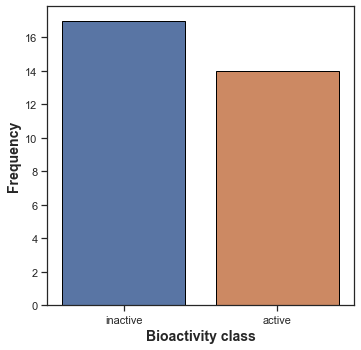

In [22]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_class', data=df_final, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

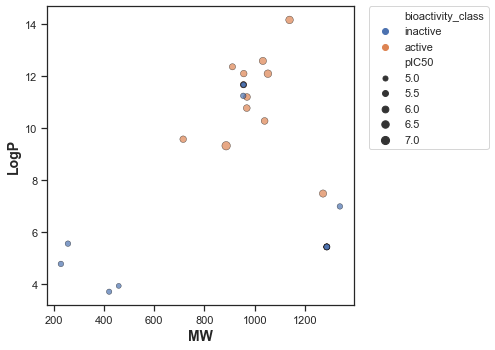

In [23]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_final, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

### **Box plots**

#### **pIC50 value**

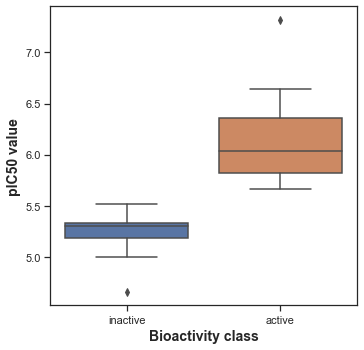

In [24]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'pIC50', data = df_final)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [25]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'bioactivity_class']
  df = df_final[selection]
  active = df[df.bioactivity_class == 'active']
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class']
  df = df_final[selection]
  inactive = df[df.bioactivity_class == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'
  
  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [26]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,238.0,0.000003,0.05,Different distribution (reject H0)


#### **MW**

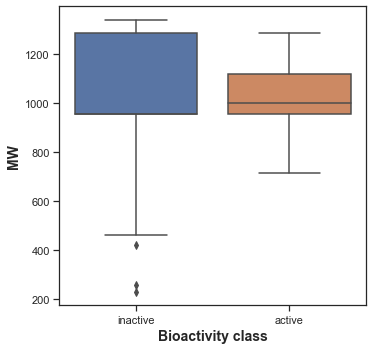

In [27]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_final)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [28]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,112.0,0.795386,0.05,Same distribution (fail to reject H0)


#### **LogP**

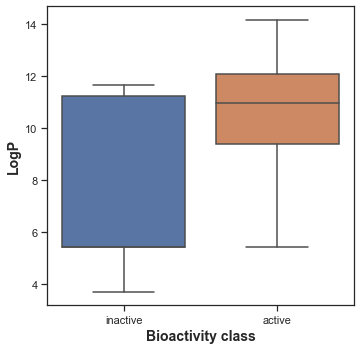

In [29]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'LogP', data = df_final)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [30]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,181.0,0.014144,0.05,Different distribution (reject H0)


#### **NumHDonors**

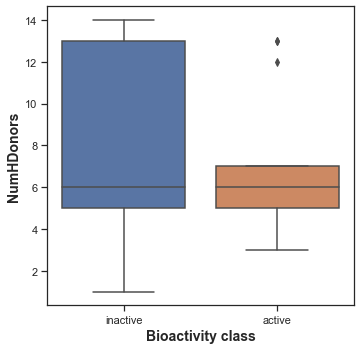

In [31]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data = df_final)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [32]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,108.0,0.670863,0.05,Same distribution (fail to reject H0)


#### **NumHAcceptors**

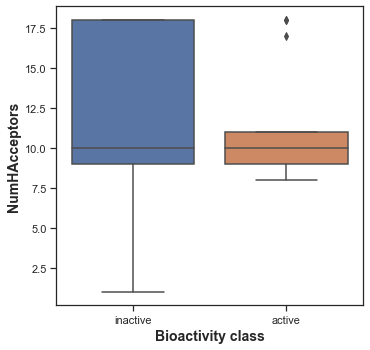

In [33]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHAcceptors', data = df_final)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [34]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,103.0,0.529883,0.05,Same distribution (fail to reject H0)


#### **Interpretation of Statistical Results**

##### **Box Plots**

###### **pIC50 values**

Taking a look at pIC50 values, the **actives** and **inactives** displayed ***statistically significant difference***, which is to be expected since threshold values (``IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives``, corresponding to ``pIC50 > 6 = Actives and pIC50 < 5 = Inactives``) were used to define actives and inactives.

###### **Lipinski's descriptors**

Of the 4 Lipinski's descriptors (MW, LogP, NumHDonors and NumHAcceptors), only LogP exhibited ***no difference*** between the **actives** and **inactives** while the other 3 descriptors (MW, NumHDonors and NumHAcceptors) shows ***statistically significant difference*** between **actives** and **inactives**.